In [4]:
import requests
import pandas as pd
import time

In [2]:
# my topics
topics = ["Basketball", "Cars", "Food", "Economy"]

### Scrape Online Wikipedia Text Data Using Wikipedia API

In [ ]:
# create empty list to hold all the data extracted
total_data = []

# create a for loop to go through each of the main topics to explore articles
for topic in topics:
    # search through Wikipedia API
    wikiAPIurl = "https://en.wikipedia.org/w/api.php"
    # search API documentation for parameters
        
    # different API expected key words for request
    # grabbing 50 articles for each topic group
    apisearchparams = {
        "action": "query",
        "format": "json",
        "list": "search",
        "srsearch": topic,
        "srlimit": 50
    }
    
    # create header for Wikipedia so it knows which script is making the request
    headers = {
        "User-Agent" : "WikipediaTextAnalysisProject/3.0"
    }
    # send request to wiki API
    search_request = requests.get(wikiAPIurl, params=apisearchparams, headers=headers)
    # throw error if request fails
    search_request.raise_for_status()
    # return response into python dictionary and store it in search_result
    search_result = search_request.json()
    
    #time.sleep(1)
    
    # article was not found, then skip to next topic
    # uses a nested dictionary
    if not search_result["query"]["search"]:
        continue
    
    # loop through artcles and grab the article titles/summary
    for article in search_result["query"]["search"]:
        # grab article title
        article_title = article["title"]
        
        # extract page summary
        # grab the first paragraph of article for summary
        summaryparams = {
            "action": "query",
            "format": "json",
            "prop": "extracts",
            "exintro": True,
            "explaintext": True,
            "titles": article_title
        }
        # sending request again to API
        summary_request = requests.get(wikiAPIurl, params=summaryparams, headers=headers)
        summary_request.raise_for_status()
        summary_result = summary_request.json()
        
        time.sleep(1)
        
        # store page id and skip wiki article if no page id exists or page id is "-1"
        wikipage_id = next(iter(summary_result["query"]["pages"]))
        if wikipage_id == "-1":
            continue
        
        # convert the json dictionary into plain text that is more readable
        # use query key to go to pages key and then go extract the page summary
        text_summary = summary_result["query"]["pages"][wikipage_id]["extract"]
        # use f string to grab the wiki url of each page that was visited
        # replaces the spaces in the title with underscores and appends the new title after "https://en.wikipedia.org/wiki/"
        wikipage_url = f"https://en.wikipedia.org/wiki/{article_title.replace(' ', '_')}"
        
        # store all the results into the total_data list as a dictionary
        total_data.append({
            "Topics": topic,
            "Title": article_title,
            "Summary": text_summary,
            "Wiki_url": wikipage_url
        })


In [72]:
df_wiki = pd.DataFrame(total_data)
df_wiki

,Topics,Title,Summary,Wiki_url
0,Basketball,Basketball,Basketball is a team sport in which two teams ...,https://en.wikipedia.org/wiki/Basketball
1,Basketball,College basketball,College basketball is basketball that is playe...,https://en.wikipedia.org/wiki/College_basketball
2,Basketball,History of basketball,Basketball began with its invention in 1891 in...,https://en.wikipedia.org/wiki/History_of_baske...
3,Basketball,National Basketball Association,The National Basketball Association (NBA) is a...,https://en.wikipedia.org/wiki/National_Basketb...
4,Basketball,Archie Miller (basketball),"Ryan Joseph ""Archie"" Miller (born October 30, ...",https://en.wikipedia.org/wiki/Archie_Miller_(b...
...,...,...,...,...
195,Economy,Wellbeing economy,Wellbeing economy is a public policy framework...,https://en.wikipedia.org/wiki/Wellbeing_economy
196,Economy,Roman economy,The study of the economies of the ancient city...,https://en.wikipedia.org/wiki/Roman_economy
197,Economy,Network economy,The network economy is the emerging economic o...,https://en.wikipedia.org/wiki/Network_economy
198,Economy,Silver economy,"Silver economy is the system of production, di...",https://en.wikipedia.org/wiki/Silver_economy


### Process the Text

In [73]:
from sklearn.feature_extraction.text import CountVectorizer
import nltk
from nltk.stem import SnowballStemmer
from nltk.corpus import stopwords

In [74]:
# tokenize the titles of each article
title_col = df_wiki["Title"]
title_tokenized = []
for title in title_col:
    tokenizer = CountVectorizer().build_tokenizer()
    title_tokenized.append(tokenizer(title))
    
# tokenize the summary of each artilce
summary_col = df_wiki["Summary"]
summary_tokenized = []
for summary in summary_col:
    tokenizer2 = CountVectorizer().build_tokenizer()
    summary_tokenized.append(tokenizer2(summary))
    
print(len(title_tokenized))
len((summary_tokenized))


200


200

**Stemming**

In [75]:
# initialize stemmer
stemmer = SnowballStemmer("english")

# apply stemming for title
stemmed_tokens_t = [] # empty list to store stemmed tokens

for title in title_tokenized:
    stem_single_title = []
    for token in title:
        stemmed = stemmer.stem(token)
        stem_single_title.append(stemmed)
    stemmed_tokens_t.append(stem_single_title)
    
# apply stemming for summary
stemmed_tokens_s = [] # empty list to store stemmed tokens

for summary in summary_tokenized:
    stem_single_title = []
    for token in summary:
        stemmed = stemmer.stem(token)
        stem_single_title.append(stemmed)
    stemmed_tokens_s.append(stem_single_title)

    

**Stopwords Removal**

In [76]:
# get English stopwords
stop_words = set(stopwords.words('english'))

# apply stemming for title
filtered_tokens_t = [] # empty list to store stemmed tokens
for title in stemmed_tokens_t:
    temp_list = []
    # "token", in this case, would be the individual words of the title
    for token in title:
        if token not in stop_words:
            temp_list.append(token)
    filtered_tokens_t.append(temp_list)
    
# apply stemming for summary
filtered_tokens_s = [] # empty list to store stemmed tokens
for summary in stemmed_tokens_s:
    temp_list = []
    # "token", in this case, would be the individual words of the summary
    for token in summary:
        if token not in stop_words:
            temp_list.append(token)
    filtered_tokens_s.append(temp_list)

**Create DTM with tf-idf Weight Scheme**

In [77]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# join tokens back into string for DTM and tf-idf

# list comprehension to join the indivdual tokens of each article title
joined_title = [' '.join(token) for token in filtered_tokens_t]

# DTM's rows are the documents and the columns are the unique words

# build the DTM with tf-idf
vectorizer = TfidfVectorizer()
dtm_tfidf = vectorizer.fit_transform(joined_title)
dtm_tfidf

<200x250 sparse matrix of type '<class 'numpy.float64'>'
	with 493 stored elements in Compressed Sparse Row format>

In [78]:
# list comprehension to join the indivdual tokens of each article summary
joined_summary = [' '.join(token) for token in filtered_tokens_s]

# build the DTM with tf-idf
vectorizer2 = TfidfVectorizer()
dtm_tfidf2 = vectorizer2.fit_transform(joined_summary)
dtm_tfidf2

<200x5186 sparse matrix of type '<class 'numpy.float64'>'
	with 18539 stored elements in Compressed Sparse Row format>

### Analyze language patterns and compare topics

In [79]:
# import sklearn package for cosine similarity
from sklearn.metrics.pairwise import cosine_similarity

# finding cosine similarity for dtm of titles
cosine_sim_t = cosine_similarity(dtm_tfidf)
title_cs = pd.DataFrame(cosine_sim_t)
#title_cs
title_mtx = np.matrix(title_cs)
title_mtx

matrix([[1.        , 0.42635048, 0.42635048, ..., 0.        , 0.        ,
         0.        ],
        [0.42635048, 1.        , 0.18177473, ..., 0.        , 0.        ,
         0.        ],
        [0.42635048, 0.18177473, 1.        , ..., 0.        , 0.        ,
         0.        ],
        ...,
        [0.        , 0.        , 0.        , ..., 1.        , 0.15820507,
         0.15820507],
        [0.        , 0.        , 0.        , ..., 0.15820507, 1.        ,
         0.15820507],
        [0.        , 0.        , 0.        , ..., 0.15820507, 0.15820507,
         1.        ]])

In [80]:
# cosine similarity of article summary dtm
cosine_sim_s = cosine_similarity(dtm_tfidf2)
summary_cs = pd.DataFrame(cosine_sim_s)
#summary_cs
summary_mtx = np.matrix(summary_cs)
summary_mtx

matrix([[1.        , 0.14474565, 0.15754638, ..., 0.00379885, 0.01344012,
         0.00908715],
        [0.14474565, 1.        , 0.09544114, ..., 0.01693255, 0.02043366,
         0.02928741],
        [0.15754638, 0.09544114, 1.        , ..., 0.04147543, 0.        ,
         0.        ],
        ...,
        [0.00379885, 0.01693255, 0.04147543, ..., 1.        , 0.09912704,
         0.04856918],
        [0.01344012, 0.02043366, 0.        , ..., 0.09912704, 1.        ,
         0.03496728],
        [0.00908715, 0.02928741, 0.        , ..., 0.04856918, 0.03496728,
         1.        ]])

Text(0.5, 1.0, 'Cosine Similarity Matrix for Summary')

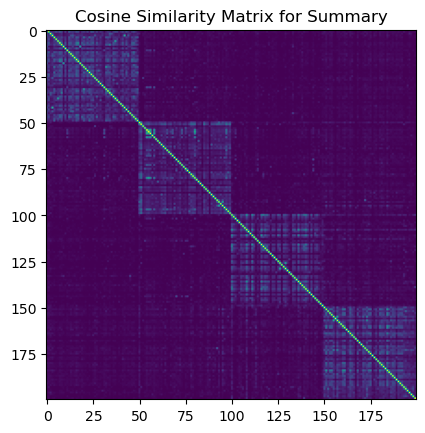

In [81]:
import matplotlib.pyplot as plt
plt.imshow(summary_mtx)
plt.title("Cosine Similarity Matrix for Summary")

Text(0.5, 1.0, 'Cosine Similarity Matrix for Title')

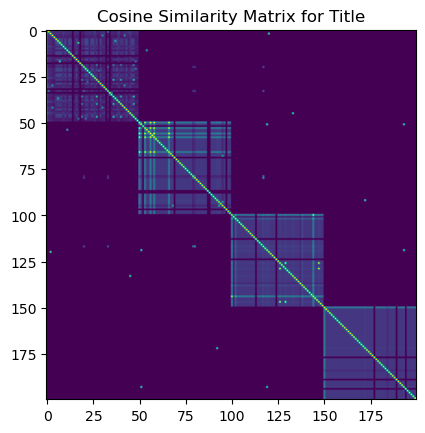

In [82]:
plt.imshow(title_mtx)
plt.title("Cosine Similarity Matrix for Title")

**Apply Thresholds to Cosine Similarity Matrix**

**Article Title Cosine Similarity Matrix**

In [83]:
# function used to apply threshold to matrix
def thresh_transform(cs_matrix, thresh):
    some_matrix = cs_matrix.copy()
    for i in range(0, 200):
        for j in range(0, 200):
            if some_matrix[i,j] >= thresh:
                some_matrix[i,j] = 1
            else: 
                some_matrix[i,j] = 0
    return plt.imshow(some_matrix)


**Title Thresholds**

Text(0.5, 1.0, 'Title 0.05')

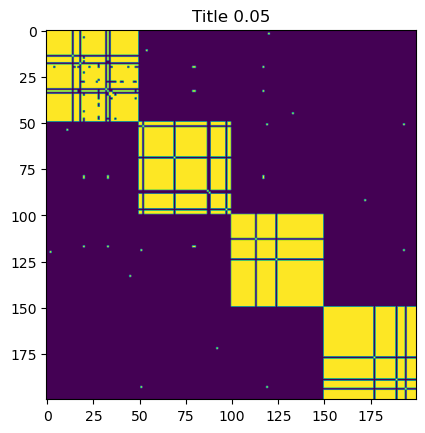

In [84]:
# treshold for matrix
thresh1 = 0.05

# 0.05 threshold gives me diagonal blocks that are clearly visible and clean, and the clusters match my 4 topic groups, and there isn't too much cross topic activity

# transforming article title matrix
thresh_transform(title_mtx, thresh1)
plt.title("Title 0.05")

Text(0.5, 1.0, 'Title 0.1')

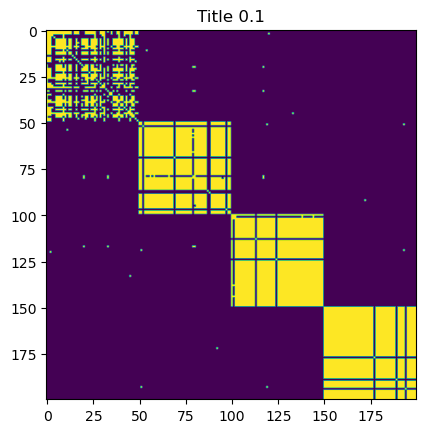

In [85]:
# treshold for matrix
thresh2 = 0.1

# transforming article title matrix
thresh_transform(title_mtx, thresh2)
plt.title("Title 0.1")

Text(0.5, 1.0, 'Title 0.2')

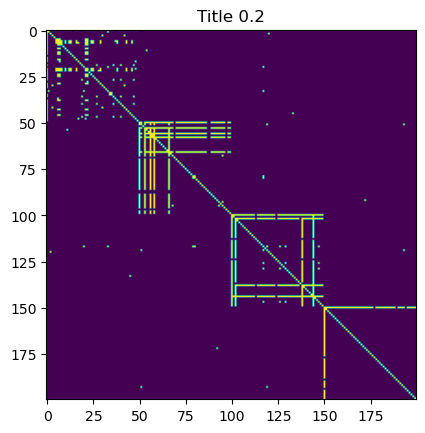

In [86]:
# treshold for matrix
thresh3 = 0.2

# transforming article title matrix
thresh_transform(title_mtx, thresh3)
plt.title("Title 0.2")

Text(0.5, 1.0, 'Title 0.4')

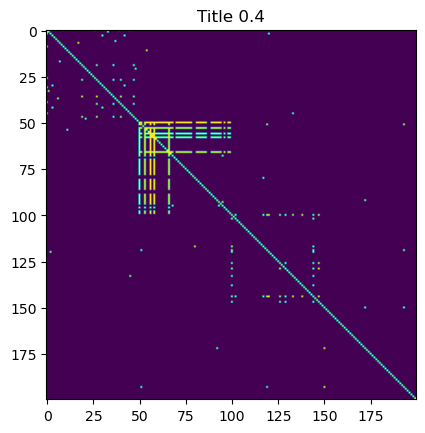

In [87]:
thresh4 = 0.4
thresh_transform(title_mtx, thresh4)
plt.title("Title 0.4")

Text(0.5, 1.0, 'Title 0.6')

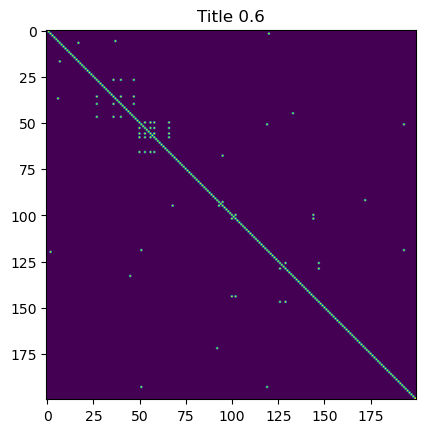

In [88]:
thresh5 = 0.6
thresh_transform(title_mtx, thresh5)
plt.title("Title 0.6")

**Summary Thresholds**

Text(0.5, 1.0, 'Summary 0.05')

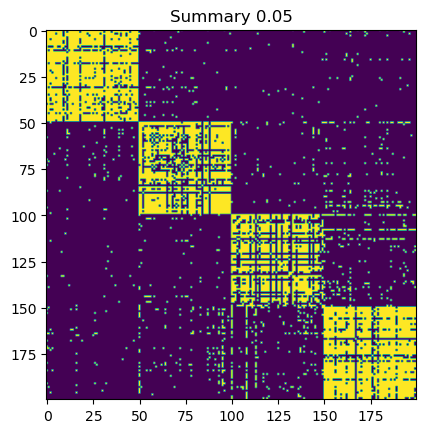

In [89]:
# transforming article summary matrix
thresh_transform(summary_mtx, thresh1)
plt.title("Summary 0.05")

Text(0.5, 1.0, 'Summary 0.1')

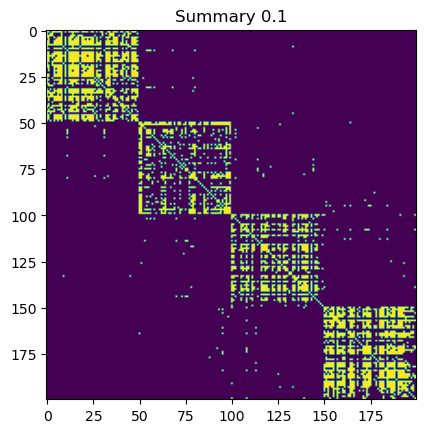

In [90]:
thresh_transform(summary_mtx, thresh2)
plt.title("Summary 0.1")

Text(0.5, 1.0, 'Summary 0.2')

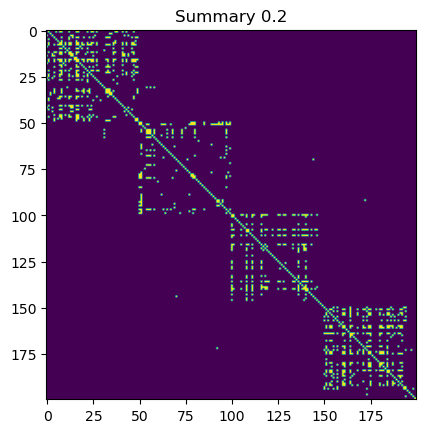

In [91]:
thresh_transform(summary_mtx, thresh3)
plt.title("Summary 0.2")

Text(0.5, 1.0, 'Summary 0.4')

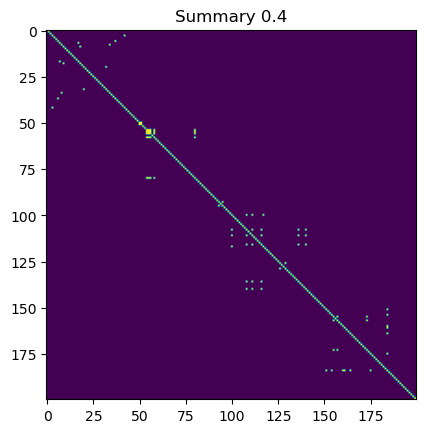

In [92]:
thresh_transform(summary_mtx, thresh4)
plt.title("Summary 0.4")

Text(0.5, 1.0, 'Summary 0.6')

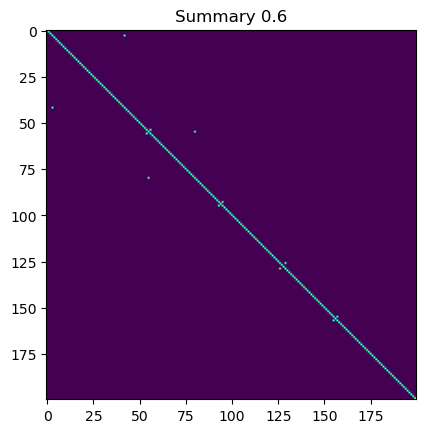

In [93]:
thresh_transform(summary_mtx, thresh5)
plt.title("Summary 0.6")

### Generate Word Cloud

In [94]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

**Title Word Clouds**

In [95]:
# grab the article titles and separate them by topic per 50
wikiTitle = df_wiki["Title"]
Title1 = wikiTitle[0:50]
Title2 = wikiTitle[50:100]
Title3 = wikiTitle[100:150]
Title4 = wikiTitle[150:200]

# used .tolist() function to turn the column into a list
title1_list = Title1.tolist()
title2_list = Title2.tolist()
title3_list = Title3.tolist()
title4_list = Title4.tolist()

# then joined the list to have a long sentence of text for the word cloud
jointitle1 = ' '.join(title1_list)
jointitle2 = ' '.join(title2_list)
jointitle3 = ' '.join(title3_list)
jointitle4 = ' '.join(title4_list)


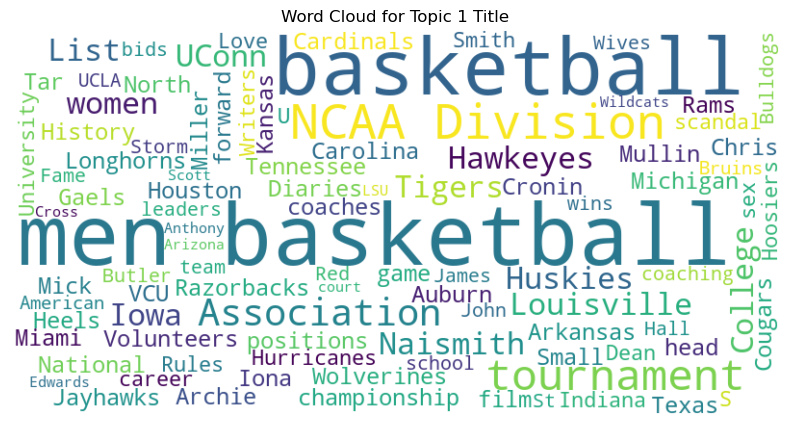

In [96]:
# word cloud for title topic 1
# long text, separated each word by a space, for the word cloud to configure
topic1text = jointitle1

# create a wordcloud object
wordcloud_t1 = WordCloud(width = 800, height = 400, background_color = "white").generate(topic1text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_t1, interpolation = "bilinear")
plt.axis("off") # hides axis
plt.title("Word Cloud for Topic 1 Title")
plt.show()


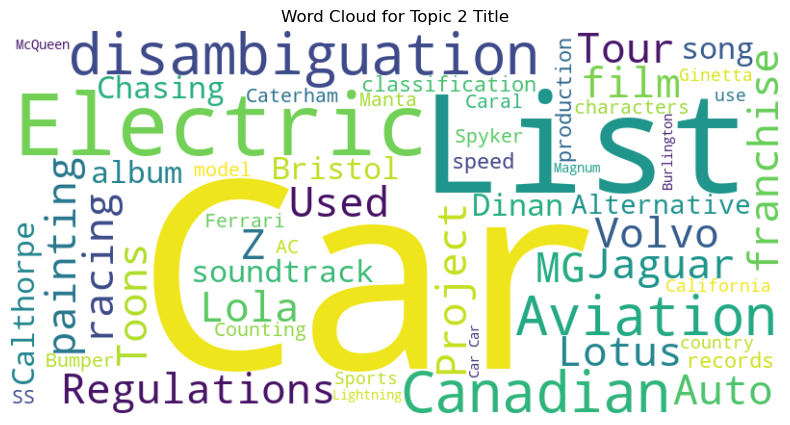

In [97]:
# word cloud for title topic 2
topic2text = jointitle2

# create a wordcloud object
wordcloud_t2 = WordCloud(width = 800, height = 400, background_color = "white").generate(topic2text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_t2, interpolation = "bilinear")
plt.axis("off") # hides axis
plt.title("Word Cloud for Topic 2 Title")
plt.show()

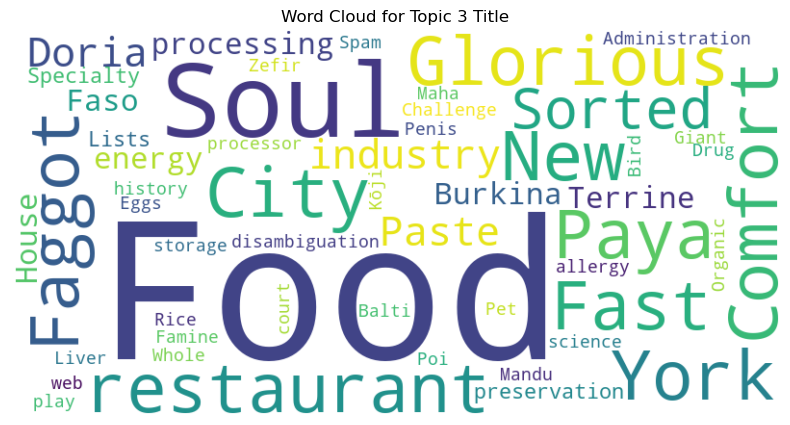

In [98]:
# word cloud for title topic 3
topic3text = jointitle3

# create a wordcloud object
wordcloud_t3 = WordCloud(width = 800, height = 400, background_color = "white").generate(topic3text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_t3, interpolation = "bilinear")
plt.axis("off") # hides axis
plt.title("Word Cloud for Topic 3 Title")
plt.show()

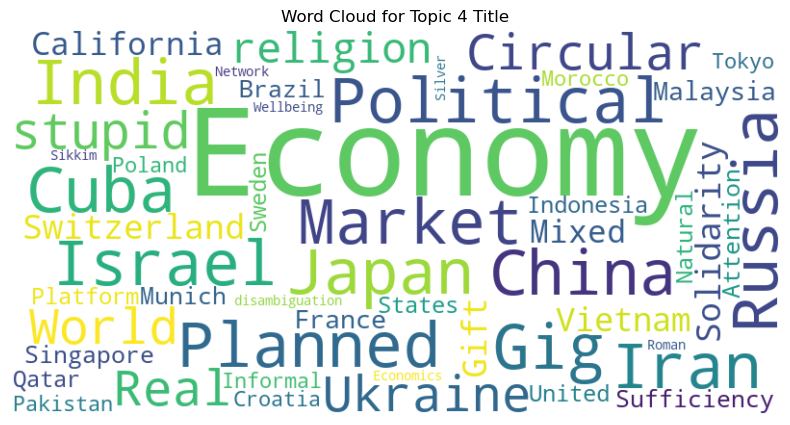

In [99]:
# word cloud for title topic 4
topic4text = jointitle4

# create a wordcloud object
wordcloud_t4 = WordCloud(width = 800, height = 400, background_color = "white").generate(topic4text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_t4, interpolation = "bilinear")
plt.axis("off") # hides axis
plt.title("Word Cloud for Topic 4 Title")
plt.show()

**Summary Word Clouds**

In [100]:
# word cloud for the article summary

# grab the article summaries and separate them by topic per 50
wikiSummary = df_wiki["Summary"]

# each of these is a series
Summary1 = wikiSummary[0:50]
Summary2 = wikiSummary[50:100]
Summary3 = wikiSummary[100:150]
Summary4 = wikiSummary[150:200]

# used .tolist() function to turn the column into a list
summary1_list = Summary1.tolist()
summary2_list = Summary2.tolist()
summary3_list = Summary3.tolist()
summary4_list = Summary4.tolist()

# then joined the list to have a long sentence of text for the word cloud
joinsummary1 = ' '.join(summary1_list)
joinsummary2 = ' '.join(summary2_list)
joinsummary3 = ' '.join(summary3_list)
joinsummary4 = ' '.join(summary4_list)

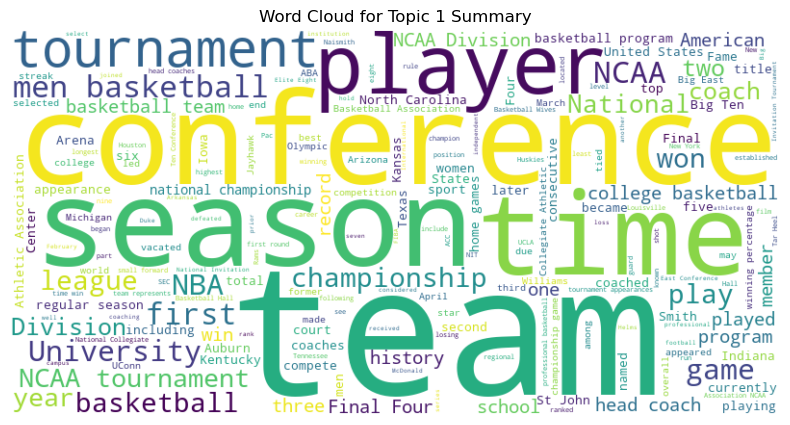

In [101]:
# word cloud for article summary 1
# long text, separated each word by a space, for the word cloud to configure
summary1text = joinsummary1

# create a wordcloud object
wordcloud_s1 = WordCloud(width = 800, height = 400, background_color = "white").generate(summary1text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_s1, interpolation = "bilinear")
plt.axis("off") # hides axis
plt.title("Word Cloud for Topic 1 Summary")
plt.show()

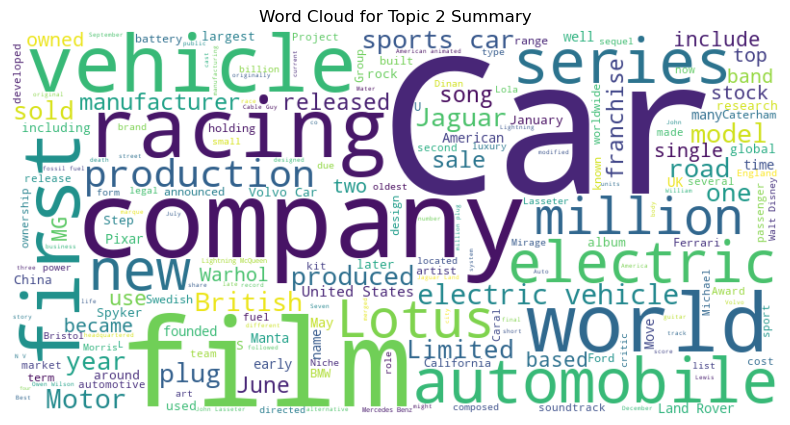

In [102]:
summary2text = joinsummary2

# create a wordcloud object
wordcloud_s2 = WordCloud(width = 800, height = 400, background_color = "white").generate(summary2text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_s2, interpolation = "bilinear")
plt.axis("off") # hides axis
plt.title("Word Cloud for Topic 2 Summary")
plt.show()

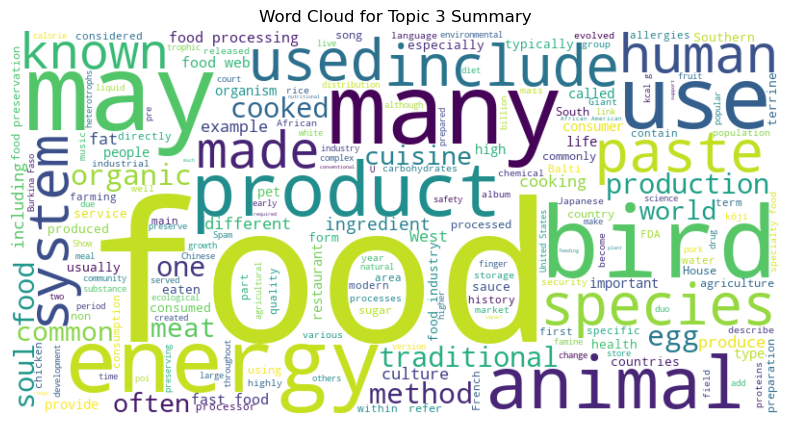

In [103]:
summary3text = joinsummary3

# create a wordcloud object
wordcloud_s3 = WordCloud(width = 800, height = 400, background_color = "white").generate(summary3text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_s3, interpolation = "bilinear")
plt.axis("off") # hides axis
plt.title("Word Cloud for Topic 3 Summary")
plt.show()

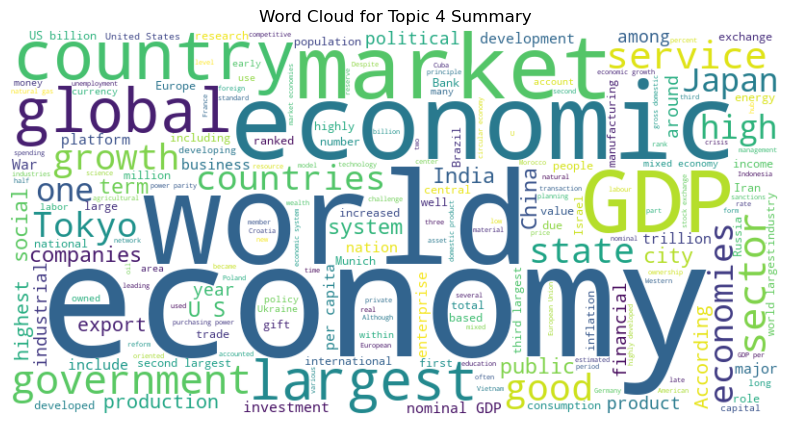

In [104]:
summary4text = joinsummary4

# create a wordcloud object
wordcloud_s4 = WordCloud(width = 800, height = 400, background_color = "white").generate(summary4text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_s4, interpolation = "bilinear")
plt.axis("off") # hides axis
plt.title("Word Cloud for Topic 4 Summary")
plt.show()

### Compute Confusion Matrix

In [105]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [106]:
cosine_sim_s.shape

(200, 200)

In [107]:
# ground truth, used to compare later with predictions, fifty 1s, 2s, 3s, and 4s for the 4 topics
# multiply each topic list by 50
truelabels = [1]*50 + [2]*50 + [3]*50 + [4]*50

# fill diagonal of cosine matrix with 0 or else confusion matrix would have no errors
np.fill_diagonal(cosine_sim_s, 0)

# return column index of max cosine similarity value for each row/article
# key component
similar_index_s = []
def similar_index(someMatrix, emptyList):
    copyMatrix = someMatrix.copy()
    for row in range(0, 200):
        # reset for each row
        max_value = 0
        max_index = 0
        for col in range(0, 200):
            val = copyMatrix[row][col]
            if val > max_value:
                max_value = val
                max_index = col
        # once the inner loop finds real max:
        emptyList.append(max_index)
            
            
# appending column index with highest cosine similarity value to empty list
similar_index(cosine_sim_s, similar_index_s)

# for each index number in the similar_index_s, output the corresponding truelabels' subset value at that index
# predicted are just subsetted true labels
predicted_s = []
def cm_prediction(anyColumn, emptyList):
    for index in anyColumn:
        predicted_value = truelabels[index]
        emptyList.append(predicted_value)
        
        
# predicting values for summary
cm_prediction(similar_index_s, predicted_s)
predicted_s

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 3,
 1,
 1,
 1,
 1,
 2,
 2,
 1,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 3,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 4,
 2,
 2,
 2,
 4,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 4,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 2,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 2,
 3,
 3,
 3,
 3,
 3,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 3,
 4,
 4,
 4,
 4,
 2,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 3]

**Confusion Matrix for Article Summary**

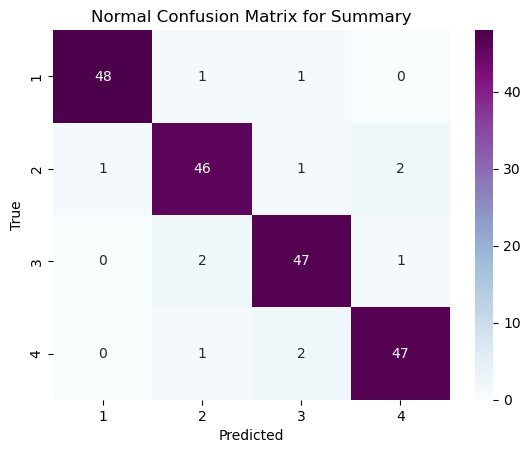

In [108]:
# confusion matrices for summary
conf_matrix1 = confusion_matrix(truelabels, predicted_s)
sns.heatmap(conf_matrix1, annot = True, cmap = "BuPu", xticklabels = [1, 2, 3, 4], yticklabels = [1, 2, 3, 4])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normal Confusion Matrix for Summary")
plt.show()

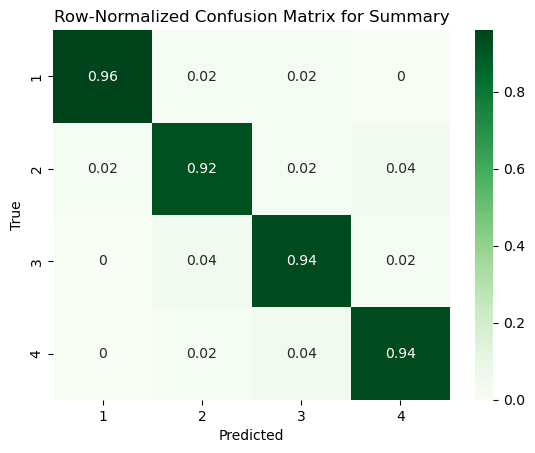

In [109]:
# axis = 1 for row
row_conf_matrix = conf_matrix1.astype("float") / conf_matrix1.sum(axis = 1)
sns.heatmap(row_conf_matrix, annot = True, cmap = "Greens", xticklabels = [1, 2, 3, 4], yticklabels = [1, 2, 3, 4])
plt.title("Row-Normalized Confusion Matrix for Summary")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

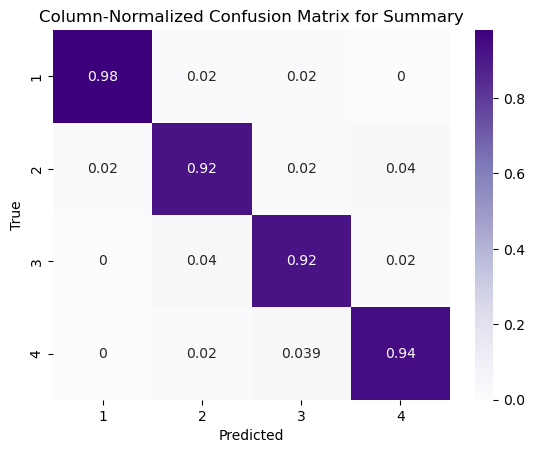

In [110]:
# axis = 0 for column
col_conf_matrix = conf_matrix1.astype("float") / conf_matrix1.sum(axis = 0)
sns.heatmap(col_conf_matrix, annot = True, cmap = "Purples", xticklabels = [1, 2, 3, 4], yticklabels = [1, 2, 3, 4])
plt.title("Column-Normalized Confusion Matrix for Summary")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

**Confusion Matrix for Article Title**

In [111]:
# title confusion matrices
np.fill_diagonal(cosine_sim_t, 0)
similar_index_t = []
similar_index(cosine_sim_t, similar_index_t)
predicted_t = []
cm_prediction(similar_index_t, predicted_t)
#predicted_t

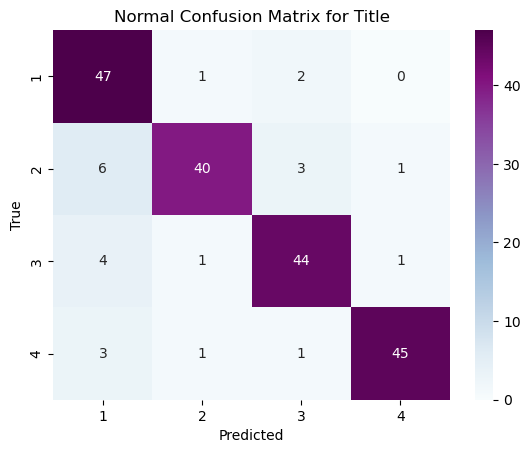

In [112]:
conf_matrix2 = confusion_matrix(truelabels, predicted_t)
sns.heatmap(conf_matrix2, annot = True, cmap = "BuPu", xticklabels = [1, 2, 3, 4], yticklabels = [1, 2, 3, 4])
plt.title("Normal Confusion Matrix for Title")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

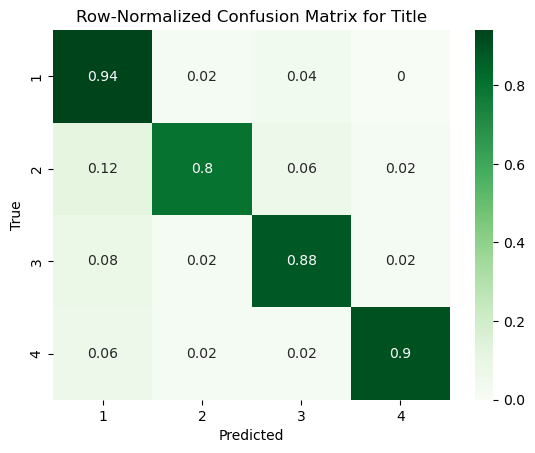

In [113]:
row_conf_matrix2 = conf_matrix2.astype("float") / conf_matrix2.sum(axis = 1)
sns.heatmap(row_conf_matrix2, annot = True, cmap = "Greens", xticklabels = [1, 2, 3, 4], yticklabels = [1, 2, 3, 4])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Row-Normalized Confusion Matrix for Title")
plt.show()

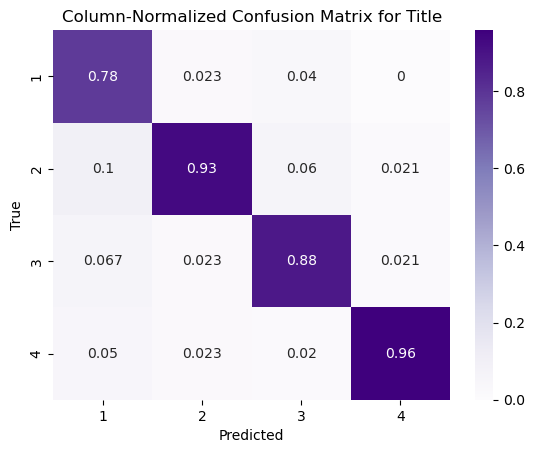

In [114]:
col_conf_matrix2 = conf_matrix2.astype("float") / conf_matrix2.sum(axis = 0)
sns.heatmap(col_conf_matrix2, annot = True, cmap = "Purples", xticklabels = [1, 2, 3, 4], yticklabels = [1, 2, 3, 4])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Column-Normalized Confusion Matrix for Title")
plt.show()